<a href="https://colab.research.google.com/github/KANISHKA-EEE/kanishka-codeboosters-2026/blob/main/Day_3/Day_3_mini_project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Employee Salary ETL Project
API Key: KANI_SIVA
Request Status Code: 200

Employee Dataset:
  First Name  Gender Start Date Last Login Time  Salary  Bonus %  \
0    Douglas    Male   8/6/1993        12:42 PM   97308    6.945   
1     Thomas    Male  3/31/1996         6:53 AM   61933    4.170   
2      Maria  Female  4/23/1993        11:17 AM  130590   11.858   
3      Jerry    Male   3/4/2005         1:00 PM  138705    9.340   
4      Larry    Male  1/24/1998         4:47 PM  101004    1.389   

  Senior Management             Team  
0              True        Marketing  
1              True              NaN  
2             False          Finance  
3              True          Finance  
4              True  Client Services  

Shape: (1000, 8)

Missing Values:
First Name            67
Gender               145
Start Date             0
Last Login Time        0
Salary                 0
Bonus %                0
Senior Management     67
Team                  43
dtype: int64

Shape After Remov

/tmp/ipykernel_1194/1514222278.py:56: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


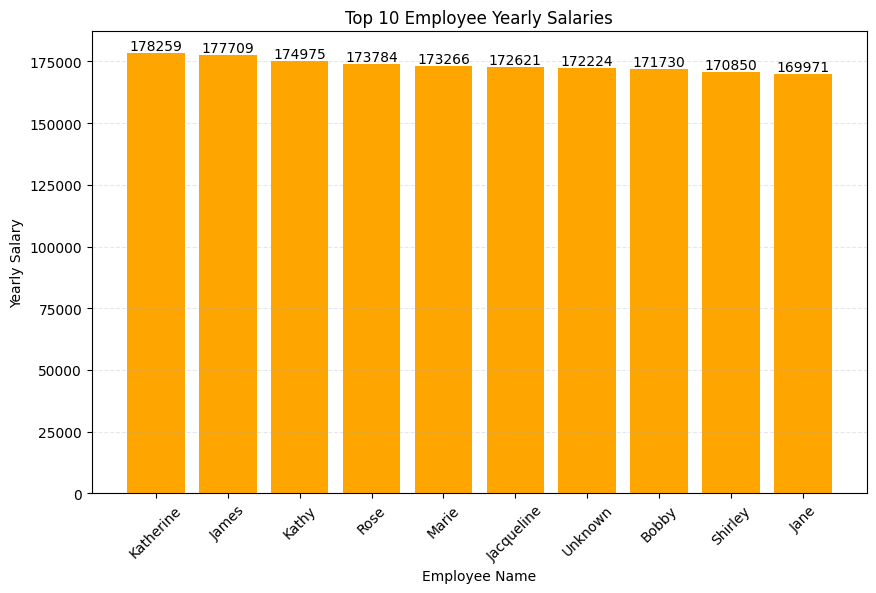


ETL Process Completed Successfully!


In [5]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import requests

#API key
API_KEY='KANI_SIVA'

print("Employee Salary ETL Project")
print("API Key:", API_KEY)

#API request
response = requests.get(
    'https://jsonplaceholder.typicode.com/users'
)

print(
    "Request Status Code:",
    response.status_code
)

#load employee dataset
employee_df = pd.read_csv('/content/employees.csv')

print("\nEmployee Dataset:")
print(employee_df.head())

print("\nShape:",
      employee_df.shape)

#missing values
print("\nMissing Values:")
print(employee_df.isnull().sum())

#remove duplicates
employee_df = employee_df.drop_duplicates()

print(
    "\nShape After Removing Duplicates:",
    employee_df.shape
)

#fill missing values
employee_df['First Name'] = (
    employee_df['First Name']
    .fillna('Unknown')
)

employee_df['Gender'] = (
    employee_df['Gender']
    .fillna('Not Specified')
)

employee_df['Senior Management'] = (
    employee_df['Senior Management']
    .fillna(False)
)

employee_df['Team'] = (
    employee_df['Team']
    .fillna('Unknown')
)

employee_df['Bonus %'] = (
    employee_df['Bonus %']
    .fillna(0)
)

#convert start date column
employee_df['Start Date'] = pd.to_datetime(
    employee_df['Start Date']
)

#calculate yearly salary
employee_df['Yearly Salary'] = (
    employee_df['Salary']
    +
    (
        employee_df['Salary']
        * employee_df['Bonus %']
        / 100
    )
)

#round values
employee_df['Yearly Salary'] = (
    employee_df['Yearly Salary']
    .round(2)
)

print("\nUpdated Dataset:")
print(employee_df.head())

#export cleaned dataset
employee_df.to_csv(
    'cleaned_employee_salary_data.csv',
    index=False
)

print(
    "\nCleaned CSV File Exported Successfully!"
)

#top 10 employees
top_salary = employee_df.sort_values(
    by='Yearly Salary',
    ascending=False
).head(10)

#visualization
fig, ax = plt.subplots(figsize=(10,6))

bars = ax.bar(
    top_salary['First Name'],
    top_salary['Yearly Salary'],
    color='orange'
)

#add labels on bars
for bar in bars:

    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.0f}",
        ha='center',
        va='bottom'
    )

#chart title
ax.set_title(
    "Top 10 Employee Yearly Salaries"
)

#axis labels
ax.set_xlabel("Employee Name")

ax.set_ylabel("Yearly Salary")

#rotate names
plt.xticks(rotation=45)

#grid
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

#show graph
plt.show()

print(
    "\nETL Process Completed Successfully!"
)